# Downloading bathymetry data

Each `load_*` function fetches data for a bounding box or preset region and returns an `xarray.DataArray`. Use `save_path` to cache downloads to disk so repeat runs skip the network request.

In [1]:
from pathlib import Path

import bathy

Path("data").mkdir(exist_ok=True)

## GEBCO (global, ~450 m / 15 arc-second)

The default global dataset, served via THREDDS from CEDA. Specify `year` to choose a release (2019--2025, default 2025).

In [2]:
data = bathy.load_gebco_opendap(
    lon_range=(-7, -5),
    lat_range=(48, 49),
    save_path="data/gebco.nc",
)
data

<xarray.DataArray 'elevation' (lat: 241, lon: 481)> Size: 232kB
array([[-157, -160, -162, ...,  -53,  -52,  -52],
       [-156, -160, -161, ...,  -52,  -53,  -52],
       [-154, -159, -161, ...,  -53,  -54,  -53],
       ...,
       [-131, -131, -131, ..., -108, -108, -108],
       [-131, -131, -131, ..., -101, -102, -101],
       [-130, -130, -131, ..., -102, -103, -102]],
      shape=(241, 481), dtype=int16)
Coordinates:
  * lat      (lat) float64 2kB 48.0 48.01 48.01 48.01 ... 48.99 48.99 49.0 49.0
  * lon      (lon) float64 4kB -6.998 -6.994 -6.99 ... -5.006 -5.002 -4.998
Attributes:
    standard_name:       height_above_mean_sea_level
    long_name:           Elevation relative to sea level
    units:               m
    grid_mapping:        crs
    sdn_parameter_urn:   SDN:P01::BATHHGHT
    sdn_parameter_name:  Sea floor height (above mean sea level) {bathymetric...
    sdn_uom_urn:         SDN:P06::ULAA
    sdn_uom_name:        Metres

(<Figure size 1000x800 with 2 Axes>,
 <Axes: xlabel='Longitude (°)', ylabel='Latitude (°)'>)

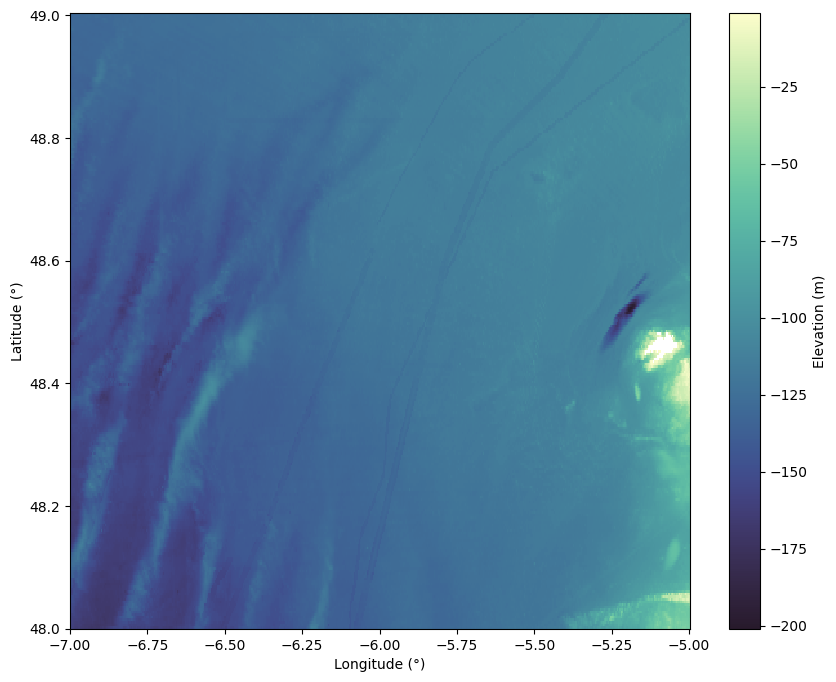

In [3]:
bathy.plot_bathy(data)

## ETOPO 2022 (global, 60s / 30s / 15s)

NOAA's integrated relief model. Choose resolution with the `resolution` parameter: `'60s'` (1 arc-min), `'30s'`, or `'15s'`.

In [4]:
data = bathy.load_etopo(
    lon_range=(-7, -5),
    lat_range=(48, 49),
    resolution="60s",
    save_path="data/etopo.nc",
)
data

/Users/euansoutter/Dropbox (Personal)/python/bathy/.venv/lib/python3.12/site-packages/pydap/handlers/dap.py:184: UserWarning: PyDAP was unable to determine the DAP protocol defaulting to DAP2. DAP2 is consider legacy and may result in slower responses. 
Consider replacing `http` in your `url` with either `dap2` or `dap4` to specify the DAP protocol (e.g. `dap2://<data_url>` or `dap4://<data_url>`).  For more 
information, go to https://www.opendap.org/faq-page.
  warnings.warn(


<xarray.DataArray 'z' (lat: 60, lon: 120)> Size: 29kB
array([[-159.96178 , -163.37134 , -166.11586 , ...,  -52.416428,
         -51.212402,  -51.44745 ],
       [-156.43286 , -160.82138 , -163.7687  , ...,  -55.656662,
         -54.877617,  -55.119053],
       [-152.19221 , -158.28627 , -161.24602 , ...,  -48.4787  ,
         -44.326805,  -38.11177 ],
       ...,
       [-132.0846  , -131.96843 , -131.71295 , ..., -103.115906,
        -102.69657 , -102.39416 ],
       [-130.61887 , -131.20354 , -130.72855 , ..., -102.81133 ,
        -102.76439 , -102.714134],
       [-130.73991 , -130.45969 , -130.33319 , ..., -102.77101 ,
        -102.50226 , -102.404945]], shape=(60, 120), dtype=float32)
Coordinates:
  * lat      (lat) float64 480B 48.01 48.03 48.04 48.06 ... 48.96 48.97 48.99
  * lon      (lon) float64 960B -6.992 -6.975 -6.958 ... -5.042 -5.025 -5.008
Attributes:
    long_name:      z
    grid_mapping:   crs
    units:          meters
    positive:       up
    standard_name:  height
    vert_crs_name:  EGM2008
    vert_crs_epsg:  EPSG:3855
    _ChunkSizes:    [1350, 2700]

(<Figure size 1000x800 with 2 Axes>,
 <Axes: xlabel='Longitude (°)', ylabel='Latitude (°)'>)

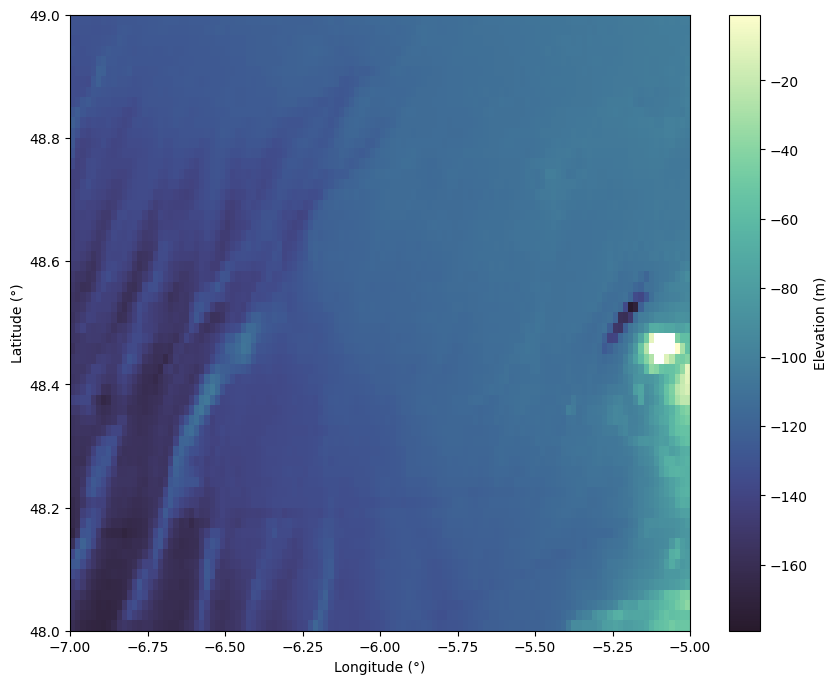

In [5]:
bathy.plot_bathy(data)

## EMODnet (European seas, ~115 m)

High-resolution gridded bathymetry for European maritime areas. Requires `owslib`: `uv pip install owslib`.

In [6]:
data = bathy.load_emodnet_wcs(
    lon_range=(-7, -5),
    lat_range=(48, 49),
    save_path="data/emodnet.tif",
)
data

<xarray.DataArray (lat: 480, lon: 960)> Size: 2MB
[460800 values with dtype=float32]
Coordinates:
  * lat          (lat) float64 4kB 48.0 48.0 48.01 48.01 ... 48.99 49.0 49.0
  * lon          (lon) float64 8kB -6.999 -6.997 -6.995 ... -5.005 -5.003 -5.001
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    AREA_OR_POINT:           Area
    scale_factor:            1.0
    add_offset:              0.0

## NOAA Coastal Relief Model (US coasts, ~90 m / 3 arc-second)

The correct regional volume (1--10) is selected automatically based on the bounding box.

In [7]:
data = bathy.load_noaa_crm(
    lon_range=(-71, -70),
    lat_range=(41, 42),
    save_path="data/crm.nc",
)
data

/Users/euansoutter/Dropbox (Personal)/python/bathy/.venv/lib/python3.12/site-packages/pydap/handlers/dap.py:184: UserWarning: PyDAP was unable to determine the DAP protocol defaulting to DAP2. DAP2 is consider legacy and may result in slower responses. 
Consider replacing `http` in your `url` with either `dap2` or `dap4` to specify the DAP protocol (e.g. `dap2://<data_url>` or `dap4://<data_url>`).  For more 
information, go to https://www.opendap.org/faq-page.
  warnings.warn(


<xarray.DataArray 'z' (lat: 1201, lon: 1201)> Size: 6MB
array([[-47.1, -47.1, -47.1, ..., -23.1, -22.8, -22.6],
       [-47.1, -47. , -47. , ..., -23.2, -23. , -22.8],
       [-47. , -47. , -46.9, ..., -23.2, -23.1, -23. ],
       ...,
       [ 23. ,  23. ,  23. , ..., -11.7, -12.3, -12.9],
       [ 23. ,  23. ,  23. , ..., -12.1, -12.8, -13.4],
       [ 16. ,  16. ,  16. , ..., -16.5, -17.1, -17.6]],
      shape=(1201, 1201), dtype=float32)
Coordinates:
  * lat      (lat) float64 10kB 41.0 41.0 41.0 41.0 41.0 ... 42.0 42.0 42.0 42.0
  * lon      (lon) float64 10kB -71.0 -71.0 -71.0 -71.0 ... -70.0 -70.0 -70.0
Attributes:
    long_name:     z
    actual_range:  [-2754.39990234375, 1903.0]
    units:         meters
    positive:      up

(<Figure size 1000x800 with 2 Axes>,
 <Axes: xlabel='Longitude (°)', ylabel='Latitude (°)'>)

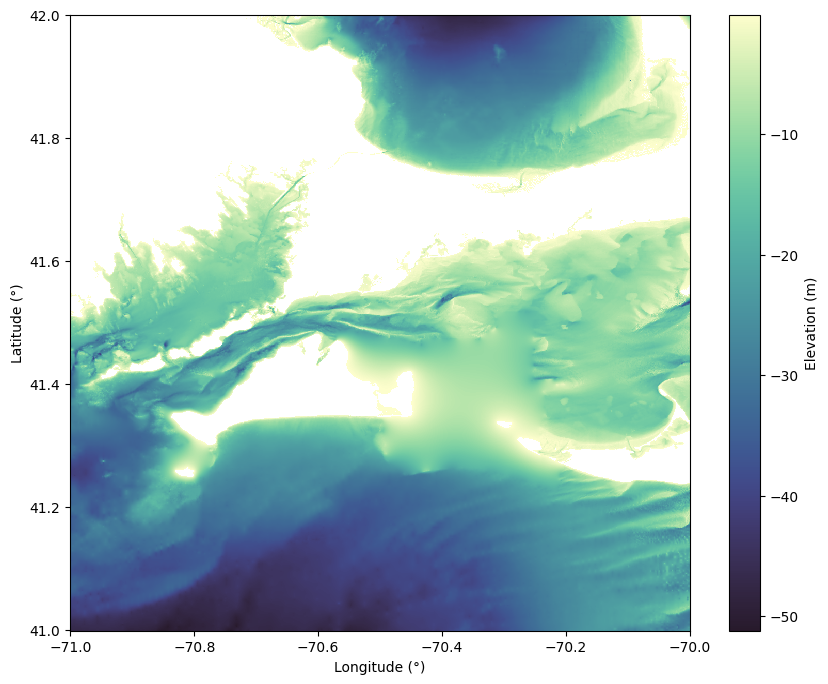

In [8]:
bathy.plot_bathy(data)

## Preset regions

Any function that accepts `lon_range` / `lat_range` also accepts a `region` name.

In [9]:
bathy.list_regions()

['arabian_sea',
 'baltic_sea',
 'bay_of_bengal',
 'black_sea',
 'caribbean',
 'coral_sea',
 'east_pacific_rise',
 'east_pacific_rise_full',
 'europe_west_coast',
 'galapagos',
 'greenland',
 'gulf_of_mexico',
 'indian_ocean_ridge',
 'japan_trench',
 'java_trench',
 'mariana_trench',
 'mediterranean',
 'mid_atlantic_ridge',
 'north_atlantic',
 'north_sea',
 'persian_gulf',
 'philippine_trench',
 'red_sea',
 'south_china_sea',
 'southwest_indian_ridge',
 'tasman_sea',
 'us_east_coast',
 'us_west_coast']

In [10]:
data = bathy.load_gebco_opendap(
    region="mariana_trench",
    save_path="data/mariana.nc",
)
data

<xarray.DataArray 'elevation' (lat: 1201, lon: 1921)> Size: 5MB
array([[-2288, -2365, -2397, ..., -4825, -4816, -4800],
       [-2267, -2326, -2356, ..., -4846, -4835, -4818],
       [-2258, -2294, -2317, ..., -4853, -4847, -4834],
       ...,
       [-4917, -4921, -4926, ..., -5354, -5353, -5321],
       [-4940, -4935, -4942, ..., -5352, -5348, -5323],
       [-4958, -4953, -4957, ..., -5344, -5339, -5319]],
      shape=(1201, 1921), dtype=int16)
Coordinates:
  * lat      (lat) float64 10kB 10.0 10.01 10.01 10.01 ... 14.99 14.99 15.0 15.0
  * lon      (lon) float64 15kB 140.0 140.0 140.0 140.0 ... 148.0 148.0 148.0
Attributes:
    standard_name:       height_above_mean_sea_level
    long_name:           Elevation relative to sea level
    units:               m
    grid_mapping:        crs
    sdn_parameter_urn:   SDN:P01::BATHHGHT
    sdn_parameter_name:  Sea floor height (above mean sea level) {bathymetric...
    sdn_uom_urn:         SDN:P06::ULAA
    sdn_uom_name:        Metres

(<Figure size 1000x800 with 2 Axes>,
 <Axes: xlabel='Longitude (°)', ylabel='Latitude (°)'>)

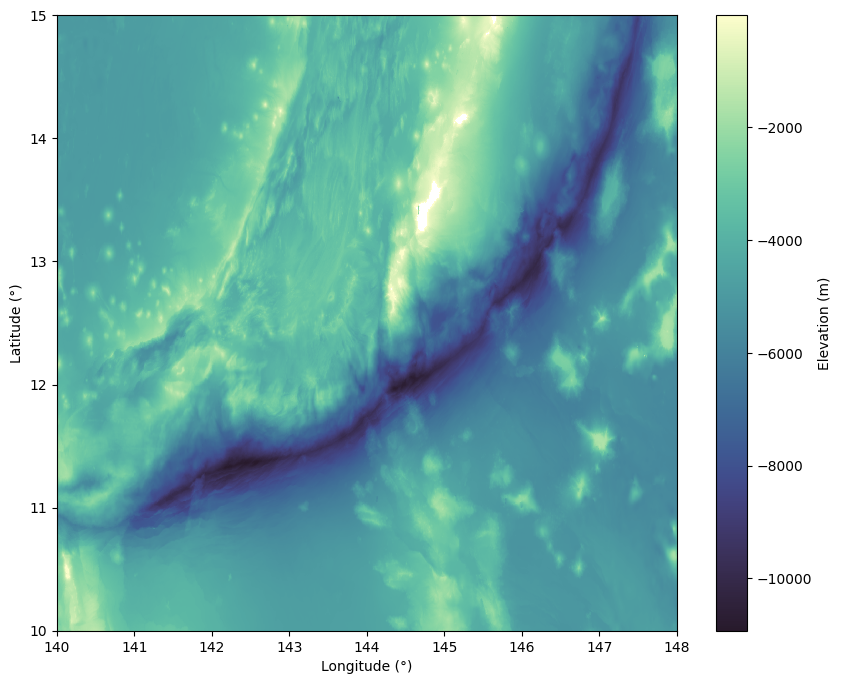

In [11]:
bathy.plot_bathy(data)

## Local files

Load any NetCDF or GeoTIFF you already have on disk.

In [12]:
# data = bathy.load_bathymetry("my_survey.nc", lon_range=(-10, -5), lat_range=(50, 55))
# data = bathy.load_bathymetry("elevation.tif")